<a href="https://colab.research.google.com/github/omelikechi/ipss/blob/main/simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install ipss and import libraries


In [ ]:
%pip install -q ipss

from ipss import ipss
import matplotlib.pyplot as plt
import numpy as np

## Generate data
1. Generate coefficient vector $\beta$ with `n_signals` randomly located nonzero entries
2. Draw `n` samples of `p`-dimensional features from multivariate normal with covariance `Sigma`
3. Generate continuous response `y` according to specified signal-to-noise ratio, `snr`

Change `Sigma` to generate features following different distributions.

In [16]:
n = 100  # number of samples
p = 200  # number of features
snr = 2  # signal-to-noise ratio

# generate beta
n_signals = 10  # number of "true" features
indices = np.random.choice(np.arange(p), size=n_signals, replace=False)  # randomly select true indices
beta = np.zeros(p)
beta[indices] = np.random.normal(0,1,size=n_signals)
truth = (beta != 0).astype(int)

# generate features
Sigma = np.eye(p)
X = np.random.multivariate_normal(np.zeros(p), Sigma, size=n)

# generate response
signal = X @ beta
sigma = np.sqrt(np.var(signal) / snr)  # noise
y = signal + np.random.normal(0, sigma, size=n)

## Run IPSS

In [17]:
EFP = 1
result = ipss(X, y, EFP=EFP)

stability_paths = result['stability_paths']
scores = result['scores']
threshold = result['threshold']

## Plot results

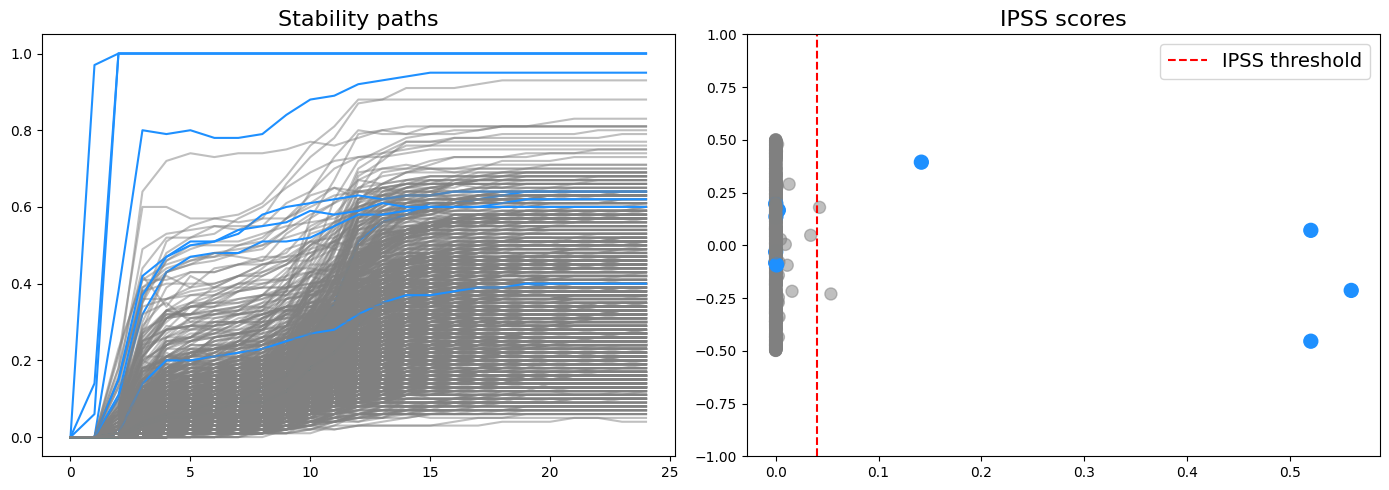

In [18]:
# specifications for visualization
color = ['dodgerblue' if value == 1 else 'gray' for value in truth]. # true features are blue
alpha = [1 if value == 1 else 0.5 for value in truth]
point_size = [100 if value == 1 else 75 for value in truth]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# plot stability paths
for j in range(p):
	ax[0].plot(stability_paths[:,j], color=color[j], alpha=alpha[j])
ax[0].set_title(f'Stability paths', fontsize=16)

# plot ipss scores (selected features are those whose scores exceed threshold)
noise = np.random.uniform(-.5, .5, size=p)
ax[1].scatter(scores, noise, color=color, alpha=alpha, s=point_size)
ax[1].axvline(threshold, linestyle='--', color='red', label=f'IPSS threshold')
ax[1].legend(loc='best', fontsize=14)
ax[1].set_ylim(-1,1)
ax[1].set_title(f'IPSS scores', fontsize=16)

plt.tight_layout()